In [ ]:
# Goal: Implement PCA on a sample matrix. Find a sweet spot between using an API that does everything for you, 
# and doing things a bit more manually (So maybe implement both, and compare). Use SVD

import torch
from matplotlib import pyplot as plt
from rich import print as pprint


N = 10
n = 5

X = torch.rand(N, n)
Xc = X - X.mean(0, keepdim=True)


U, S, Vt = torch.linalg.svd(Xc, full_matrices=False)

V = Vt.T

k = 2
X_proj = Xc @ V[:, :k]


plt.matshow(Xc)
plt.matshow(X_proj)

X_rec = X_proj @ V[:, :k].T
plt.matshow(X_rec)


# We have 10 data points, they are embedded in a 5D space.
# We want to find the directions which, when the points are projected onto them, the variance of the data is maximized
# Or another way to find the directions are directions which, when the points are projected onto them, the distance the points traveled minimized
# The first direction should be the most variance maximizing one
# These directions are called principal components
# Each principle component is going to be a vector of length 5
# With SVD: X = (somematrix)(some_matrix, with every row being like a direction that the data is stretched to)(some_matrix, which is like the scoring of how effective the principle componnents are)

first_pc = torch.rand(n,2)

projection = X @ first_pc

pprint(projection)



In [ ]:
Cov = (Xc.T @ Xc) / (N - 1)
eigvals, eigvecs = torch.linalg.eigh(Cov)
eigvals, eigvecs = eigvals.flip(0), eigvecs.flip(1)

print("Eigenvalues (variance explained):", eigvals)
print("Eigen vectors (principle components:)", eigvecs)

k = 2
V_k = eigvecs[:, :k]
X_proj = Xc @ V_k

X_recon = X_proj @ V_k.T

plt.figure(figsize=(10,5))
plt.subplot(1,3,1)
plt.matshow(Xc, fignum=False)
plt.subplot(1,3,2)
plt.matshow(X_recon, fignum=False)
plt.show()

plt.scatter(X_proj[:, 0], X_proj[:, 1])
plt.show()
plt.scatter(X_proj[:, 0], X_proj[:, 1])
plt.show()

# ROUND 2

In [ ]:
import torch
from matplotlib import pyplot as plt

N = 10
n = 5

X = torch.randn(N, n)
Xc = X - X.mean(0, keepdim=True)

A, B, C = torch.linalg.svd(Xc)

## This works but I don't know what is actually going on, I want a bit fine grained understanding of what is happening
## So I know a covariance matrix is calculated, and then eigen vectors are calculated and then they are used for something

cov = (Xc @ Xc.T ) / (N-1)## Or something like that 
eigvals, eigvecs  = torch.linalg.eigh(cov)
eigvals, eigvecs = eigvals.flip(0), eigvecs.flip(1)

plt.matshow(eigvecs)

# plt.figure()
# plt.subplot(1,2,1)
# plt.matshow(A, fignum=False)
# plt.subplot(1,2,2)
# plt.matshow(C, fignum=False)
# plt.show()
# print(B)


k = 3
X_proj = Xc @ C[:, :k]
X_recon = X_proj @ C[:, :k].T

# plt.figure()
# plt.subplot(1,3,1)
# plt.matshow(X_proj, fignum=False)
# plt.subplot(1,3,2)
# plt.matshow(Xc, fignum=False)
# plt.subplot(1,3,3)
# plt.matshow(X_recon, fignum=False)
# plt.show()


thing = C
plt.matshow(thing)
plt.matshow(A)


# ROUND 3

In [ ]:
import torch
from matplotlib import pyplot as plt

torch.manual_seed(1)

N = 10
n = 5
k = 5
X = torch.randn(N, n)
Xc = X - X.mean(0, keepdim=True)

Cov = Xc.T @ Xc / (N - 1)

eigvals, eigvecs = torch.linalg.eigh(Cov)#, fullmatrixes=False)
eigvals, eigvecs = eigvals.flip(0), eigvecs.flip(1)

print(eigvecs.shape)

X_proj = Xc @ eigvecs[:, :k]
X_recon = X_proj @ eigvecs[:, :k].T
plt.figure(figsize=(3,3))
plt.subplot(1,2,1)
plt.matshow(Xc, fignum=False)
plt.subplot(1,2,2)
plt.matshow(X_recon, fignum=False)


A, B, C = torch.linalg.svd(Xc, full_matrices=False)

X_proj = Xc @ C[:, :k]
X_recon = X_proj @ C[:, :k].T
plt.figure(figsize=(3,3))
plt.subplot(1,2,1)
plt.matshow(X_recon, fignum=False)
plt.subplot(1,2,2)
plt.matshow(Xc, fignum=False)


plt.figure(figsize=(3,3))
plt.subplot(1,2,1)
plt.matshow(C,fignum=False)
plt.title('C')
plt.subplot(1,2,2)
plt.matshow(eigvecs,fignum=False)
plt.title('eigvecs')
plt.show()

print(eigvecs.sum(), C.sum())


In [ ]:
import numpy as np
vectors = np.array([[2,1], [-1,2], [1,-2]])

plt.figure()
for v in vectors:
    plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1)

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.gca().set_aspect('equal')
plt.grid(True)
plt.show()

# ROUND 4

tensor([[ 0.1381,  0.8838],
        [-0.8660, -0.0356],
        [ 1.8549, -0.2126],
        [ 0.1939, -0.2016],
        [-0.5600,  0.0932],
        [-0.7679,  0.1788],
        [-1.1295,  0.6113],
        [ 0.7740,  1.3260],
        [-0.3142, -1.4032],
        [ 0.6766, -1.2401]])

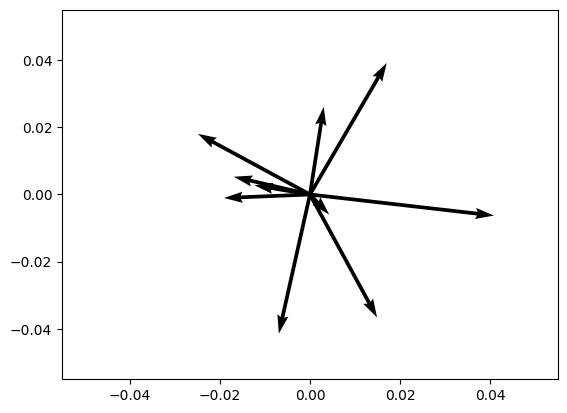

A tensor([[ 0.0776, -0.3451],
        [ 0.2805,  0.1471],
        [-0.6411, -0.2093],
        [-0.0920,  0.0438],
        [ 0.1976,  0.0526],
        [ 0.2781,  0.0534],
        [ 0.4575, -0.0490],
        [-0.0704, -0.6056],
        [-0.0919,  0.5627],
        [-0.3958,  0.3495]]) B tensor([2.7941, 2.5145]) C tensor([[-0.9211,  0.3893],
        [-0.3893, -0.9211]])

In [23]:
import torch
from matplotlib import pyplot as plt
from rich import print as pprint

# torch.manual_seed(0)

N = 10
n = 2

X = torch.randn(N,n)
Xc = X - X.mean(0, keepdim=True)
pprint(Xc)

for i in range(N):
  plt.quiver(0, 0, Xc[i,0], Xc[i,1], scale=5)

plt.gca() # I HAVE TO SCALE THIS THING SO IT MAKES SENSE VISUALLY
plt.show()


A, B, C = torch.linalg.svd(Xc, full_matrices=False)
pprint('A', A,'B', B,'C',C)

In [ ]:
k = 1
X_proj = Xc @ C[:, :k]
pprint(X_proj)
X_recon = X_proj @ C[:, :k].T
pprint(X_recon)

for i in range(N):
  plt.quiver(0, 0, X_recon[i,0], X_recon[i,1],scale=5)
  

In [ ]:
Ck = C[:, :k]
Ckt = Ck.T
pprint(Ck)
pprint(Ckt)

plt.quiver(0, 0, Ck[0], Ck[1], scale=5)
plt.quiver(0,0,Ckt[0,1],Ckt[0,0] , scale=1)

In [ ]:
import plotly.graph_objects as go
import numpy as np

v = np.array([1, 2, 3])

fig = go.Figure()
fig.add_trace(go.Cone(
    x=[0], y=[0], z=[0],
    u=[v[0]], v=[v[1]], w=[v[2]],
    sizemode="absolute"
))
fig.show()


# Round 5

[[ 1.446692   -0.70484238 -0.07761569]
 [-1.25062199  0.77232166 -1.85098263]
 [ 1.5671584  -0.85429287  0.76959516]
 [-0.42702374  1.36902197 -1.60958465]
 [-0.50007057 -0.47714032  1.58432551]
 [-1.27754463 -0.26551418 -0.42730235]
 [-0.13543962  0.48972925 -0.65006311]
 [ 0.96707035  0.80850475  0.9530504 ]
 [ 0.72320259 -0.77681383  0.32766584]
 [-1.1134228  -0.36097405  0.98091153]]

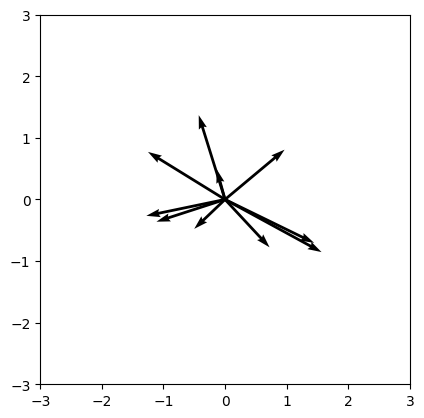

In [60]:
import torch
import numpy as np
from matplotlib import pyplot as plt
from rich import print as pprint

np.random.seed(1)

N = 10
n = 3
X = np.random.randn(N,n)
Xc = X - X.mean(0, keepdims=True)

for i in range(N):
  plt.quiver(0, 0, Xc[i, 0], Xc[i, 1], scale=1, angles='xy', scale_units='xy')

pprint(Xc)
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-3, 3)
plt.ylim(-3, 3)

plt.show()
